In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append('../../datasets')
from load_data import get_datasets

2025-02-03 11:08:36.281253: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
params = {'input_shape': [6000, 1], 'classes_filter': [], 'num_classes': 12}
ds_train, ds_val, ds_test, class_weights = get_datasets("speech_commands", params)

labels = {0: 'down', 1: 'go', 2: 'left', 3: 'no', 4: 'off', 5: 'on', 6: 'right', 7: 'stop', 8: 'up', 9: 'yes', 10: '_silence_', 11: '_unknown_'}


2025-02-03 11:08:39.458849: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-03 11:08:39.550880: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-03 11:08:39.552639: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-02-03 11:08:39.555279: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the approp

In [4]:
from nutil.plot import paperStyle
import seaborn as sns
import librosa

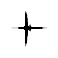

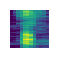

In [12]:
i = 0
for X, y in ds_train.take(20):
    if i == 8:
        with paperStyle():
            plt.figure(figsize=(0.5, 0.5))
            plt.plot(X, lw=0.2, color='black')
            plt.axis('off')
            
            plt.savefig('audio.svg', bbox_inches='tight', dpi=300)
            plt.show()
        break
    i += 1

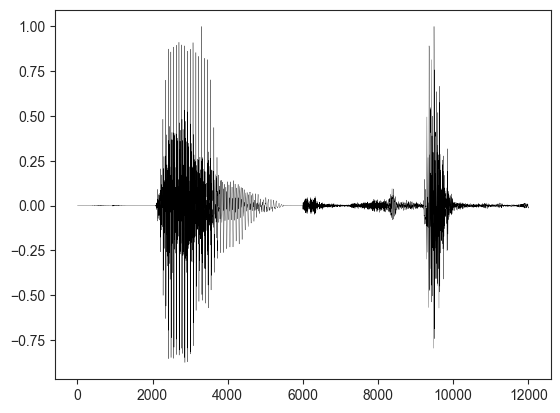

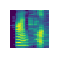

In [19]:
two_inputs = []
for X, y in ds_train.take(2):
    two_inputs.append(X)

X = np.concatenate(two_inputs, axis=0)
X = X.reshape(-1)
plt.plot(X, lw=0.2, color='black')
plt.show()

# calculate mel spectrogram and save it
mel = librosa.feature.melspectrogram(y=X.flatten(), sr=16000, n_mels=128, fmax=8000)
mel = librosa.power_to_db(mel, ref=np.max)
mel = mel[:, :100]
mel = np.flipud(mel)

plt.figure(figsize=(0.5, 0.5))
sns.heatmap(mel, cmap='viridis', cbar=False)
plt.axis('off')
plt.savefig('mel.svg', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
i = 0
for X, y in ds_train.take(20):
    if i == 8:
        with paperStyle():
            plt.figure(figsize=(0.5, 0.5))
            plt.plot(X, lw=0.2, color='black')
            plt.axis('off')
            
            plt.savefig('audio.svg', bbox_inches='tight', dpi=300)
            plt.show()
        break
    i += 1            

In [30]:
def get_class_distribution(ds):
    labels = [np.argmax(label) for _, label in ds]
    return np.bincount(labels, minlength=12)

In [31]:
train_distribution = get_class_distribution(ds_train)
val_distribution = get_class_distribution(ds_val)
test_distribution = get_class_distribution(ds_test)

In [32]:
def plot_distribution(distribution, title):
    fig, ax = plt.subplots()
    ax.pie(distribution, labels=labels, autopct='%1.1f%%')
    ax.axis('equal')
    plt.title(title)
    plt.show()


In [ ]:
plot_distribution(train_distribution, 'Train distribution')
plot_distribution(val_distribution, 'Validation distribution')
plot_distribution(test_distribution, 'Test distribution')

In [ ]:
# print raw numbers of samples presented nicely in a table in markdown
print('| Class | Train | Validation | Test |')
print('|-------|-------|------------|------|')
for i in range(12):
    print(f'| {labels[i]} | {train_distribution[i]} | {val_distribution[i]} | {test_distribution[i]} |')
    
